# Semantic Segmentation with U-Net

In this project, you'll implement and train a U-Net model—a specialized type of convolutional neural network (CNN) designed for fast and accurate **semantic segmentation**. Unlike standard image classification, semantic segmentation assigns a class label to **each individual pixel** in an image. You’ll apply this to data from a self-driving car simulator, learning how to predict a full-resolution mask that identifies where key objects like roads, vehicles, and pedestrians are located.

While object detection draws bounding boxes around detected items, semantic segmentation provides a finer level of detail by labeling **every pixel** with its semantic category. For example, a car in the image is represented by a dense region of "car" labels, not just a rectangle. This level of precision is critical in autonomous driving applications, where systems must navigate safely through environments filled with dynamic and diverse elements.

<div align="center">
  <img src="../assets/segmentation_media/carseg.png" style="width:500px;height:250;">
  <p><b>Figure 1</b>: Example of a pixel-wise segmented scene, with cars in blue and people in red.</p>
</div>

By completing this notebook, you will:

- Build a fully functional U-Net from scratch
- Understand how U-Net differs from traditional CNNs in terms of structure and use cases
- Train your model on a semantic segmentation task using data from the CARLA self-driving car simulator
- Apply pixel-wise loss functions like sparse categorical crossentropy to optimize the model

## Import libraries and load and split the data

In [1]:
import os
import sys
from tensorflow.keras.layers import Input

# point to root dir of the repo
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

# define data paths
image_dir = os.path.join(project_root, 'data', 'segmentation', 'images')
mask_dir = os.path.join(project_root, 'data', 'segmentation', 'masks')

2025-04-30 20:34:05.821583: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Visualizing Raw Images and Masks with `preview_image_pair`

In this first visualization, we use `preview_image_pair` to display raw image and mask pairs directly from disk using `imageio.v2.imread`. This method provides the most faithful representation of the original dataset as saved, using the exact class index values and their associated color mappings from the original PNG files.

Despite using nearest-neighbor interpolation for masks, this method appears remarkably smooth and visually appealing. That's because:
- The original PNG masks use a limited, consistent color palette for class labels.
- No TensorFlow preprocessing is applied, preserving visual integrity.
- `imageio` renders the mask with cleaner, anti-aliased edges at full resolution.

This approach is ideal for verifying how the dataset appears before entering the TensorFlow pipeline.

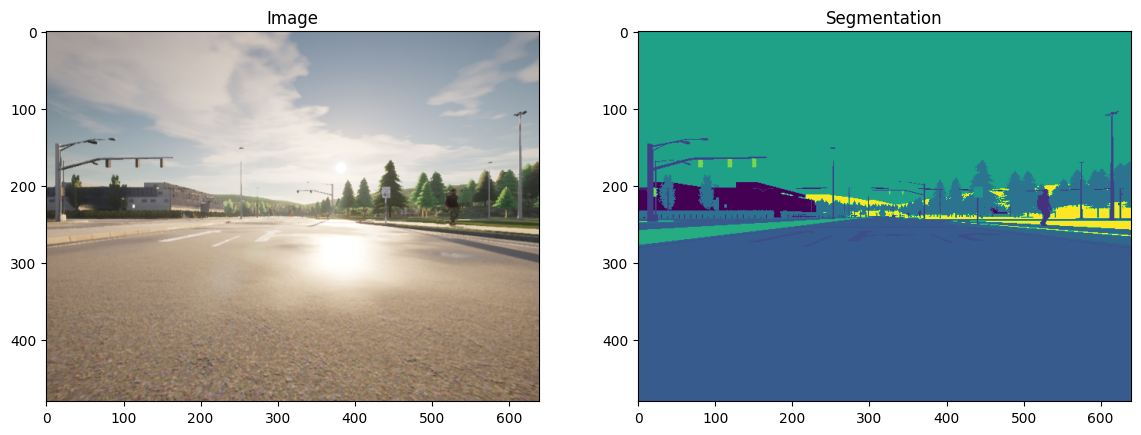

In [2]:
from src.segmentation.data_loader import (load_image_and_mask_paths, load_dataset, preview_image_pair)

image_paths, mask_paths = load_image_and_mask_paths(image_dir, mask_dir)
preview_image_pair(image_paths[25], mask_paths[25])  
dataset = load_dataset(image_paths, mask_paths, image_size=(240, 320), shuffle=True, batch_size=16)

In [3]:
# sanity check 
for img, msk in zip(image_paths[:5], mask_paths[:5]):
    print(os.path.basename(img), os.path.basename(msk))

000026.png 000026.png
000027.png 000027.png
000028.png 000028.png
000029.png 000029.png
000032.png 000032.png


### Visualizing Tensor-Formatted Images with High-Contrast Segmentation Masks

In this visualization, we use the `display()` function to inspect image and mask tensors drawn from the preprocessed `tf.data.Dataset` pipeline. Each mask is a single-channel tensor of class indices, which we convert to a visually interpretable format using a custom `label_to_rgb()` function.

This function applies the `nipy_spectral` colormap, a perceptually uniform palette that gives each class a distinct hue. This color mapping:
- Makes it easier to visually differentiate between neighboring or overlapping objects.
- Helps highlight semantic boundaries between classes.
- Provides better contrast than the raw PNG palette, especially for debugging and training inspection.

While the masks may appear more pixelated compared to the original dataset due to training-time resizing (96×128 resolution), this method makes the colorway consistent and the structure of the segmentation is clear.

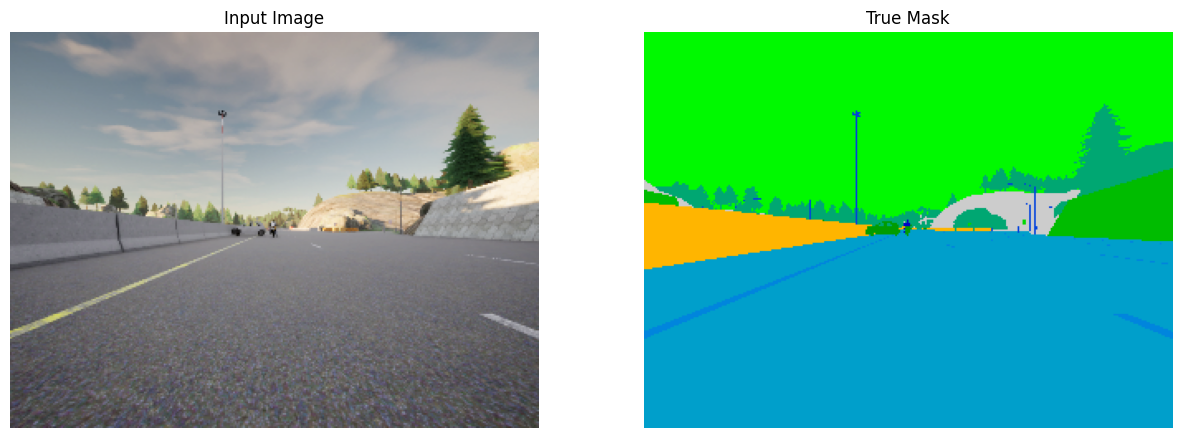

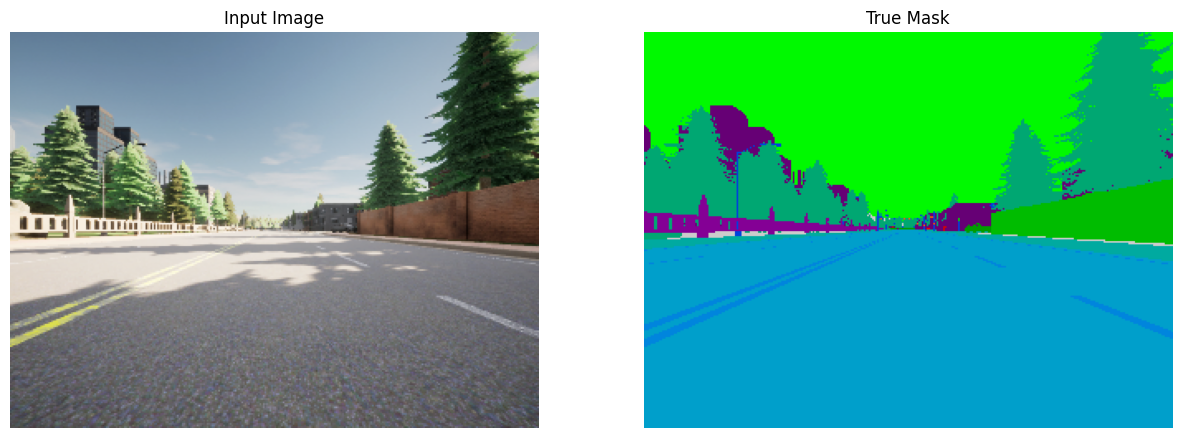

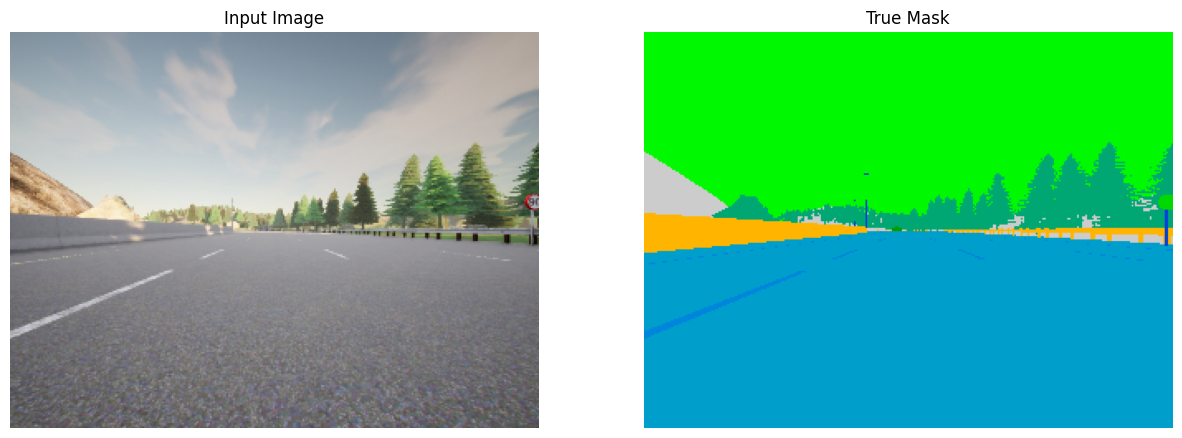

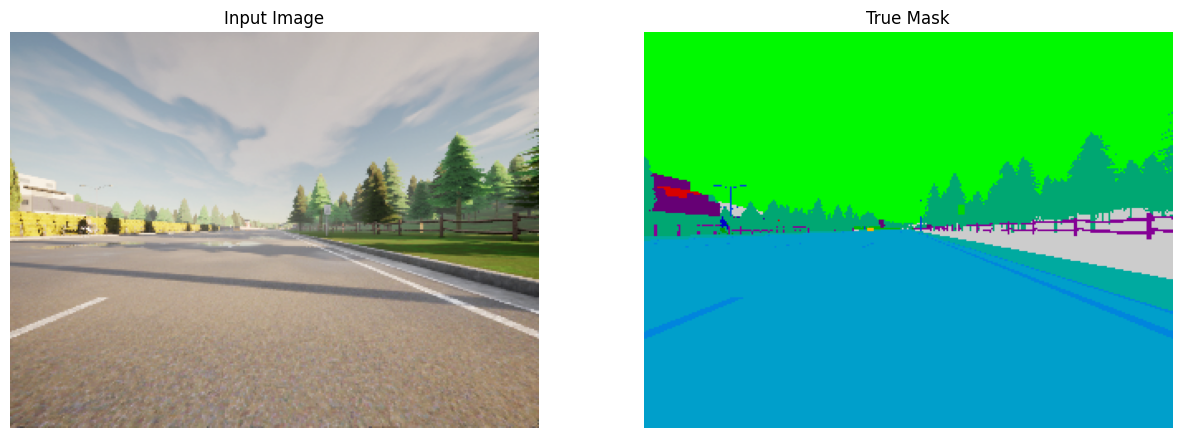

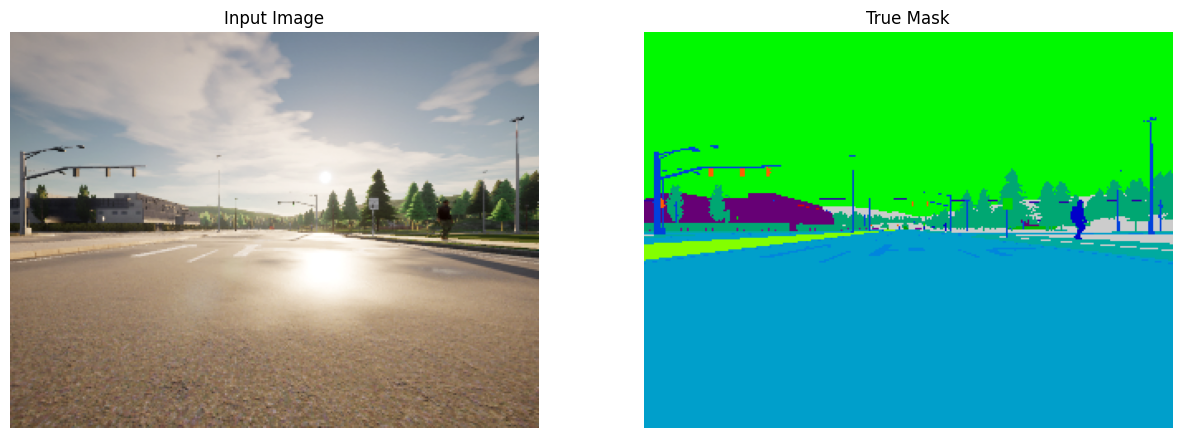

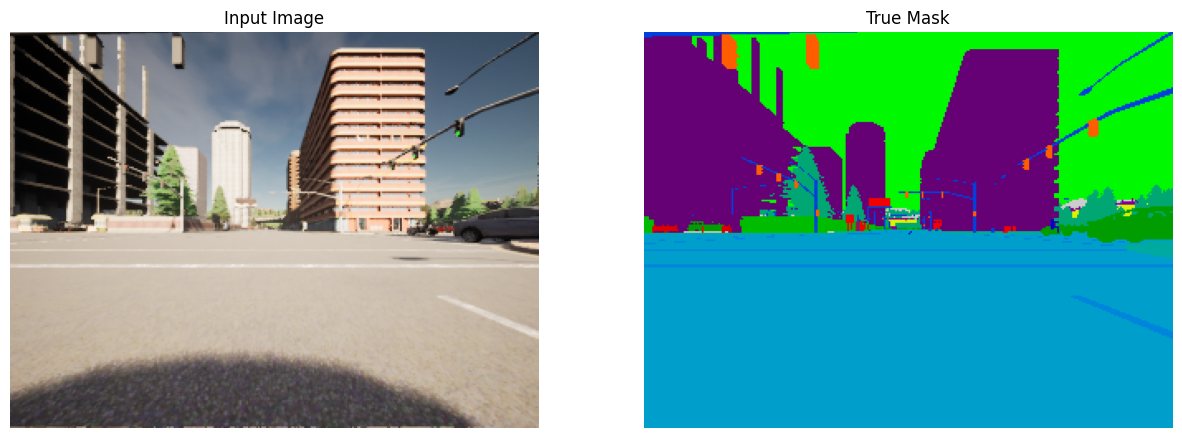

In [4]:
from src.segmentation.utils import display
for image, mask in dataset.take(6):
    display([image[0], mask[0]])

## Understanding and Building U-Net for Semantic Segmentation

The **U-Net** architecture is a powerful and efficient convolutional network designed specifically for semantic segmentation. Originally developed for biomedical image analysis, U-Net has since become a standard model across many domains, including autonomous driving, where precise, pixel-level object understanding is critical.

Unlike traditional CNNs, which are designed for classification and lose spatial detail through pooling and dense layers, U-Net maintains and recovers spatial context throughout its structure using a **symmetric encoder-decoder design** and **skip connections**. These architectural choices allow it to localize object boundaries sharply, even with relatively few training samples.


### Architectural Overview

<img src="../assets/segmentation_media/unet.png" style="width:700px;height:400;">
<caption><center><b>Figure 2:</b> U-Net Architecture</center></caption>

The model consists of three major parts:

- **Encoder (Contracting Path):** Extracts image features while reducing resolution.
- **Bottleneck:** Encodes the deepest, most abstract representation.
- **Decoder (Expanding Path):** Reconstructs the original resolution, using skip connections from the encoder to refine segmentation accuracy.

### Encoder (Downsampling Path)

<p align="center">
  <img src="../assets/segmentation_media/encoder.png" style="width:500px;height:500;">
  <br>
  <b>Figure 3:</b> The U-Net Encoder
</p>

The encoder compresses spatial information while expanding the feature dimension using:

- **Two 3×3 convolution layers** with ReLU activation (`'same'` padding)
- **Optional Dropout layers** for regularization (added in deeper blocks)
- **2×2 MaxPooling layers** to downsample the feature maps

Each block outputs:
- A **`next_layer`** to pass deeper into the encoder
- A **`skip_connection`**, captured before pooling, which will later be used by the decoder

As the network moves deeper, the number of filters is **doubled at each stage**, allowing it to capture more complex features.


### Decoder (Upsampling Path)

<p align="center">
  <img src="../assets/segmentation_media/decoder.png" style="width:500px;height:500;">
  <br>
  <b>Figure 4:</b> The U-Net Decoder
</p>

The decoder performs the reverse of the encoder—it gradually reconstructs the original spatial resolution while reducing the number of filters:

- **Conv2DTranspose layers** (3×3, stride 2) upsample the feature maps
- **Skip connections** are concatenated from the corresponding encoder block to inject spatial context lost during downsampling
- **Two 3×3 Conv2D layers** with ReLU activation refine the upsampled maps

These skip connections are vital—they provide local detail that would otherwise be lost due to aggressive pooling in the encoder.

### Building the Full U-Net

The complete U-Net model chains the encoder and decoder, with a **bottleneck** in between. The bottleneck is the deepest part of the network and uses the largest number of filters.

You’ll build the network with a progressive doubling of filters in the encoder (e.g., 64 → 128 → 256...), and a halving in the decoder (e.g., 512 → 256 → 128...). If training performance is acceptable, you may consider using the full filter configuration from the original paper, especially if your GPU can handle the added memory load.

The final layer is a **1×1 Conv2D** that outputs a tensor with a channel for each class, where each pixel's vector corresponds to its class probabilities.


### Final Output and Prediction

The output of the network is a tensor of shape `(height, width, num_classes)`, each pixel is associated with a probability distribution over all classes. To convert this into a predicted segmentation mask, we apply `argmax` across the channel dimension, assigning each pixel the class with the highest probability.


### Loss Function for Pixel-Wise Classification

For this segmentation task, the ground truth masks are stored as 2D arrays of class indices (not one-hot encoded). That means each pixel’s value is a single integer from 0 to `num_classes - 1`. As a result, we use **`SparseCategoricalCrossentropy`**, which is designed to work directly with integer class labels. It is both efficient and accurate for multiclass pixelwise classification.This loss is computed independently for each pixel and averaged over the image. It ensures that the model learns to assign high confidence to the correct class at each pixel location.

In [5]:
from src.segmentation.model_unet import conv_block

image_paths, mask_paths = load_image_and_mask_paths(image_dir, mask_dir)
dataset = load_dataset(image_paths, mask_paths)

# test block construction
inputs = Input(shape=(240, 320, 3))
block_output = conv_block(inputs, n_filters=64)

In [6]:
from src.segmentation.model_unet import upsampling_block
from tensorflow.keras import Model
from tensorflow.keras.layers import Input

input_size1 = (24, 32, 512)
input_size2 = (48, 64, 256)
n_filters = 64

expansive_inputs = Input(input_size1)
contractive_inputs = Input(input_size2)

cblock1 = upsampling_block(expansive_inputs, contractive_inputs, n_filters)
model1 = Model(inputs=[expansive_inputs, contractive_inputs], outputs=cblock1)

model1.summary()  

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 24, 32, 512)]        0         []                            
                                                                                                  
 conv2d_transpose (Conv2DTr  (None, 48, 64, 64)           294976    ['input_2[0][0]']             
 anspose)                                                                                         
                                                                                                  
 input_3 (InputLayer)        [(None, 48, 64, 256)]        0         []                            
                                                                                                  
 concatenate (Concatenate)   (None, 48, 64, 320)          0         ['conv2d_transpose[0][0]',

In [8]:
from src.segmentation.model_unet import unet_model
img_height = 240
img_width = 320
num_channels = 3
n_classes = 23

unet = unet_model((img_height, img_width, num_channels), n_filters=64, n_classes=n_classes)
unet.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 240, 320, 3)]        0         []                            
                                                                                                  
 conv2d_24 (Conv2D)          (None, 240, 320, 64)         1792      ['input_5[0][0]']             
                                                                                                  
 conv2d_25 (Conv2D)          (None, 240, 320, 64)         36928     ['conv2d_24[0][0]']           
                                                                                                  
 max_pooling2d_5 (MaxPoolin  (None, 120, 160, 64)         0         ['conv2d_25[0][0]']           
 g2D)                                                                                       

## Train the Model

In [9]:
from src.segmentation.train import compile_model, train_model

unet = unet_model((img_height, img_width, num_channels), n_filters=64, n_classes=23)
unet = compile_model(unet, n_classes=23)
model_history = train_model(unet, dataset, epochs=5)

Epoch 1/5
 1/67 [..............................] - ETA: 1:02:43 - loss: 3.5520 - accuracy: 0.0016 - iou_metric: 5.4831e-04 - dice_score: 9.4232

## Save the Model Weights

In [16]:
from src.segmentation.train import save_model_weights

save_model_weights(unet, path='outputs/segmentation/unet_weights.h5')

Weights saved to outputs/segmentation/unet_weights.h5


# Reload the weights

In [17]:
from src.segmentation.train import load_model_weights

# Re-initialize model architecture
unet = unet_model((img_height, img_width, num_channels), n_filters=32, n_classes=23)
unet = compile_model(unet, n_classes=23)

# Load weights
unet = load_model_weights(unet, path='outputs/segmentation/unet_weights.h5')

Weights loaded from outputs/segmentation/unet_weights.h5


### Visualizing Model Predictions

The `show_predictions()` function compares the U-Net’s predicted segmentation masks with the corresponding ground truth masks and input images. It uses `tf.argmax` along the class axis to extract the most likely class per pixel and visualizes the results using consistent color mappings:

1/1 [==============================] - 1s 1s/step


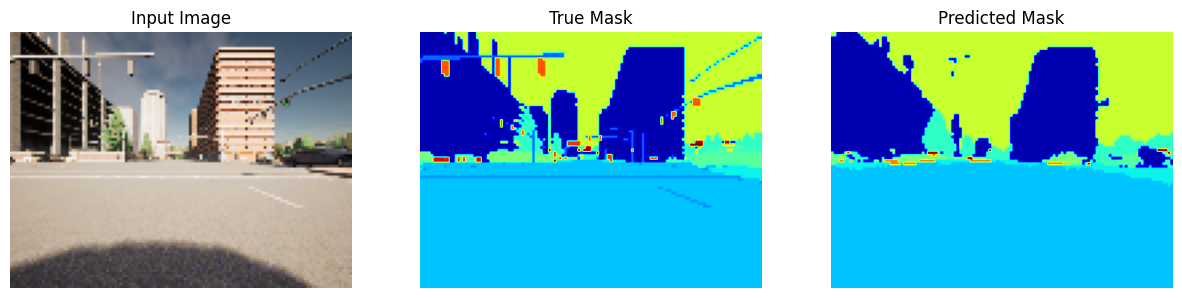

1/1 [==============================] - 1s 579ms/step


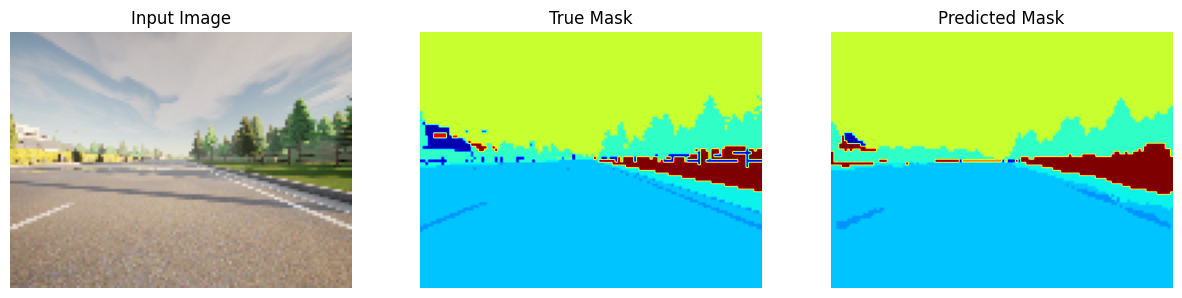

1/1 [==============================] - 1s 531ms/step


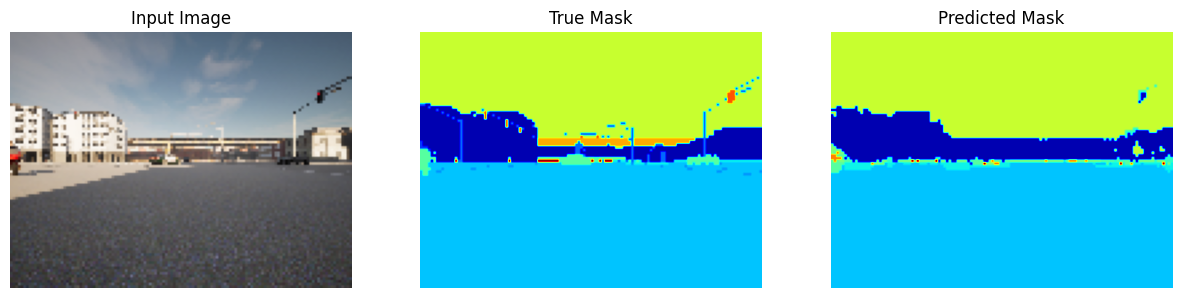

1/1 [==============================] - 0s 485ms/step


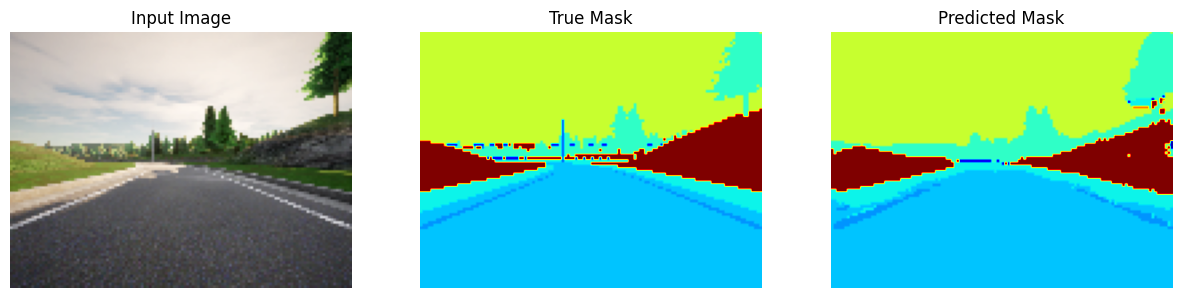

1/1 [==============================] - 1s 520ms/step


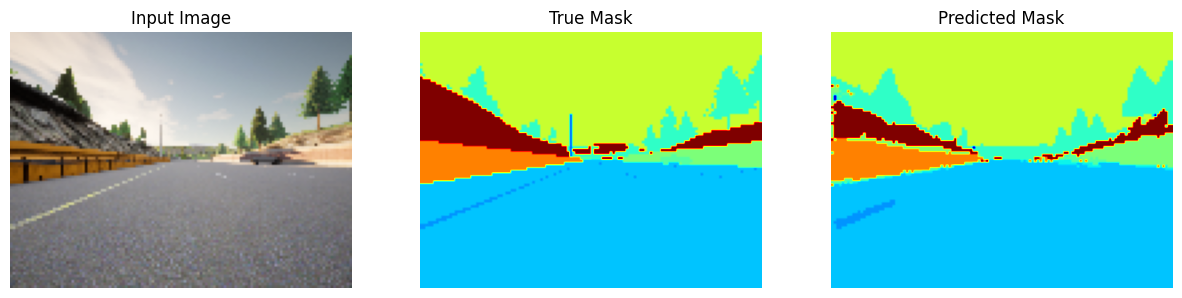

1/1 [==============================] - 1s 502ms/step


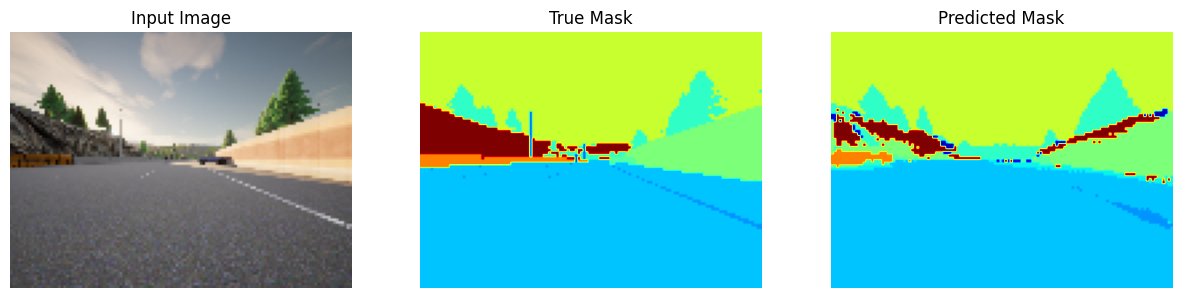

In [18]:
from src.segmentation.utils import show_predictions

show_predictions(unet, dataset, num=6)

### Visualizing Accuracy, IoU, and Dice Score

- **Accuracy** measures the percentage of correctly classified pixels. While useful, it can be misleading in imbalanced datasets where background pixels dominate.
  
- **Intersection over Union (IoU)** quantifies the overlap between predicted and true segmentation masks:
  
  $
  \text{IoU} = \frac{|A \cap B|}{|A \cup B|}
  $
  
  where \( A \) is the predicted mask and \( B \) is the ground truth. IoU penalizes false positives and false negatives but may under-represent small class performance.

- **Dice Score** (aka F1 for segmentation) gives more weight to overlapping regions, making it especially useful for evaluating smaller structures:
  
  $
  \text{Dice} = \frac{2 |A \cap B|}{|A| + |B|}
  $
  
  Compared to IoU, Dice is more sensitive to partial overlaps and class imbalance, making it the preferred metric in many medical and autonomous vision tasks.

Monitoring all three metrics helps diagnose training behavior and model generalization across different object sizes and class distributions.

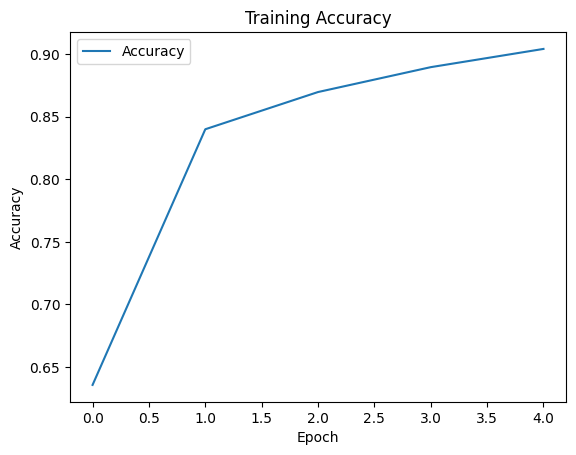

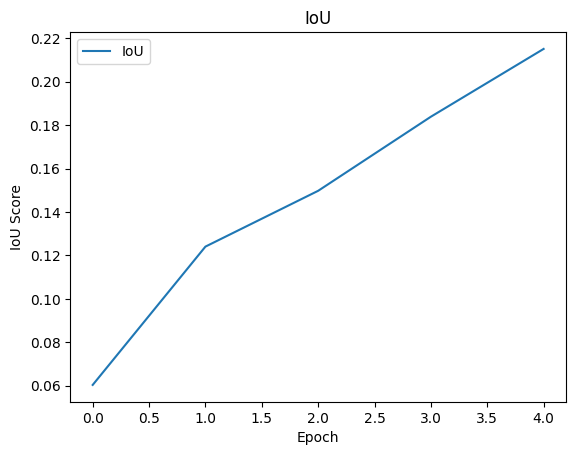

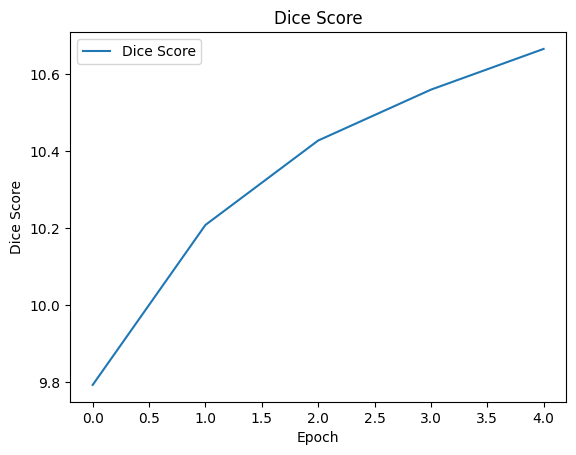

In [21]:
import matplotlib.pyplot as plt

plt.plot(model_history.history["accuracy"], label='Accuracy')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(model_history.history["iou_metric"], label='IoU')
plt.title("IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU Score")
plt.legend()
plt.show()

plt.plot(model_history.history["dice_score"], label='Dice Score')
plt.title("Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.show()